In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
words = open('data/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words), max(len(w) for w in words), min(len(w) for w in words)

(32033, 15, 2)

In [230]:
# build a vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
vocab_size = len(chars) + 1

stoi = {ch: i+1 for i, ch in enumerate(chars)}  # string to index
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}  # index to string

itos, vocab_size

({1: 'a',
  2: 'b',
  3: 'c',
  4: 'd',
  5: 'e',
  6: 'f',
  7: 'g',
  8: 'h',
  9: 'i',
  10: 'j',
  11: 'k',
  12: 'l',
  13: 'm',
  14: 'n',
  15: 'o',
  16: 'p',
  17: 'q',
  18: 'r',
  19: 's',
  20: 't',
  21: 'u',
  22: 'v',
  23: 'w',
  24: 'x',
  25: 'y',
  26: 'z',
  0: '.'},
 27)

In [ ]:
# build the dataset
block_size = 3  # how many characters do we take to predict the next one?
X_train, Y_train = [], []
for w in words[:5]:
    print(w)
    context = [0] * block_size  # initial context is all 0s (the dot)
    for ch in w + '.':
        ix = stoi[ch]
        X_train.append(context)
        Y_train.append(ix)
        print(''.join(itos[i] for i in context), '->', itos[ix])
        context = context[1:] + [ix]  # shift the window

X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

emma
... -> e
..e -> m
.em -> m
emm -> a
mma -> .
olivia
... -> o
..o -> l
.ol -> i
oli -> v
liv -> i
ivi -> a
via -> .
ava
... -> a
..a -> v
.av -> a
ava -> .
isabella
... -> i
..i -> s
.is -> a
isa -> b
sab -> e
abe -> l
bel -> l
ell -> a
lla -> .
sophia
... -> s
..s -> o
.so -> p
sop -> h
oph -> i
phi -> a
hia -> .


In [ ]:
X_train, X_train.shape, Y_train, Y_train.shape

(tensor([[ 0,  0,  0],
         [ 0,  0,  5],
         [ 0,  5, 13],
         [ 5, 13, 13],
         [13, 13,  1],
         [ 0,  0,  0],
         [ 0,  0, 15],
         [ 0, 15, 12],
         [15, 12,  9],
         [12,  9, 22],
         [ 9, 22,  9],
         [22,  9,  1],
         [ 0,  0,  0],
         [ 0,  0,  1],
         [ 0,  1, 22],
         [ 1, 22,  1],
         [ 0,  0,  0],
         [ 0,  0,  9],
         [ 0,  9, 19],
         [ 9, 19,  1],
         [19,  1,  2],
         [ 1,  2,  5],
         [ 2,  5, 12],
         [ 5, 12, 12],
         [12, 12,  1],
         [ 0,  0,  0],
         [ 0,  0, 19],
         [ 0, 19, 15],
         [19, 15, 16],
         [15, 16,  8],
         [16,  8,  9],
         [ 8,  9,  1]]),
 torch.Size([32, 3]),
 tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
          1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]),
 torch.Size([32]))

In [ ]:
C = torch.randn(27, 2)
C

(tensor([[ 0.7805, -0.0123],
         [-0.1510, -1.6869],
         [-0.8164,  0.8089],
         [ 0.9438,  0.0628],
         [ 1.3427, -1.2721],
         [-1.5733, -1.4535],
         [-1.2175,  0.6537],
         [-1.1816,  0.4308],
         [ 0.4585, -0.3888],
         [-1.2893,  0.3287],
         [-0.8074,  1.0175],
         [-0.3730, -1.6360],
         [-0.6355,  2.2195],
         [-1.6195,  0.7768],
         [-0.2625, -0.1492],
         [ 0.8512,  0.3255],
         [ 0.0682,  0.0025],
         [-1.5213,  1.0247],
         [-0.8074,  1.0983],
         [-0.5417, -1.2060],
         [ 0.7632,  0.7123],
         [ 1.2022,  0.8693],
         [ 0.1769, -0.2573],
         [ 0.4286,  0.6183],
         [ 0.0726,  0.1034],
         [-0.0972,  0.3236],
         [-2.0153,  1.1392]]),
 tensor([-1.5733, -1.4535]))

In [17]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C, C[5]

(tensor([-1.5733, -1.4535]), tensor([-1.5733, -1.4535]))

In [ ]:
emb = C[X_train]

%time
print(emb.reshape(emb.shape[0], -1).shape)

%time
print(emb.view(emb.shape[0], -1).shape)

CPU times: total: 0 ns
Wall time: 0 ns
torch.Size([32, 6])
CPU times: total: 0 ns
Wall time: 0 ns
torch.Size([32, 6])
torch.Size([32, 6])


In [41]:
W1 = torch.randn(6, 100)
b1 = torch.randn(100)

h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h, h.shape

(tensor([[ 0.8682,  0.9309, -0.5899,  ...,  0.6365, -0.8197,  0.8934],
         [ 0.9915,  0.9014, -0.9859,  ...,  0.9996, -0.9996, -0.0821],
         [ 0.9990, -0.7786, -0.9998,  ..., -0.4552, -0.9997,  0.9999],
         ...,
         [ 0.9616,  0.5594, -0.9472,  ...,  0.9590, -0.9496,  0.6321],
         [ 0.9628,  0.8553, -0.9142,  ...,  0.3678, -0.9962,  0.9881],
         [ 0.9965, -0.9385, -0.9772,  ...,  0.9983, -0.9967, -0.9788]]),
 torch.Size([32, 100]))

In [42]:
W2 = torch.randn(100, 27)
b2 = torch.randn(27)

logits = h @ W2 + b2
logits, logits.shape

(tensor([[-5.5008e+00, -1.1434e+01,  8.6367e+00,  1.3570e+01,  5.8591e+00,
          -9.3188e+00, -2.9325e+00, -6.6068e+00, -9.3292e-01,  9.3553e+00,
          -3.6138e+00,  2.8284e+00,  5.7193e+00,  9.1143e+00, -7.2526e+00,
          -6.0472e-01, -1.9178e+01, -8.1154e+00,  9.7520e-01,  8.4157e-01,
          -6.1140e+00, -6.6072e+00,  6.8521e+00,  4.1576e+00, -5.5947e+00,
          -3.4727e+00, -1.4528e+00],
         [-3.3335e+00, -7.7275e+00,  1.3371e+01,  8.6791e+00,  3.1391e+00,
           3.6981e+00, -1.3441e+00,  5.6299e+00,  8.1371e+00,  1.4392e+01,
          -8.4751e+00, -4.6835e+00, -6.0956e+00,  2.5903e+00, -8.2927e+00,
          -1.9179e+01, -1.3019e+00, -1.7029e+00,  1.3663e+01, -1.4360e+00,
          -7.9092e+00,  3.3892e+00,  1.5519e+01,  4.6741e+00,  1.1245e-01,
           1.1266e+01, -1.2692e+00],
         [ 2.5313e+00,  3.1492e-02, -6.4562e+00, -1.6004e+00,  1.1987e+00,
           4.9224e-01, -3.3452e+00,  6.1575e+00, -1.1729e+00, -9.7744e+00,
           2.4894e+00,  5.

In [44]:
probs = logits.exp() / logits.exp().sum(1, keepdim=True)
probs, probs.shape, probs[0].sum()

(tensor([[5.0389e-09, 1.3349e-11, 6.9532e-03, 9.6549e-01, 4.3239e-04, 1.1071e-10,
          6.5724e-08, 1.6672e-09, 4.8543e-07, 1.4265e-02, 3.3253e-08, 2.0876e-05,
          3.7597e-04, 1.1209e-02, 8.7407e-10, 6.7401e-07, 5.7862e-15, 3.6881e-10,
          3.2720e-06, 2.8627e-06, 2.7289e-09, 1.6665e-09, 1.1671e-03, 7.8872e-05,
          4.5872e-09, 3.8294e-08, 2.8862e-07],
         [4.0258e-09, 4.9724e-11, 7.2382e-02, 6.6352e-04, 2.6054e-06, 4.5565e-06,
          2.9434e-08, 3.1451e-05, 3.8589e-04, 2.0086e-01, 2.3545e-11, 1.0437e-09,
          2.5427e-10, 1.5049e-06, 2.8255e-11, 5.2893e-16, 3.0702e-08, 2.0560e-08,
          9.6902e-02, 2.6850e-08, 4.1462e-11, 3.3458e-06, 6.1994e-01, 1.2093e-05,
          1.2630e-07, 8.8169e-03, 3.1723e-08],
         [1.2757e-04, 1.0474e-05, 1.5943e-08, 2.0483e-06, 3.3654e-05, 1.6604e-05,
          3.5779e-07, 4.7929e-03, 3.1410e-06, 5.7739e-10, 1.2234e-04, 1.8521e-03,
          2.4193e-12, 8.7056e-11, 1.4196e-01, 1.9004e-22, 1.9576e-05, 1.2979e-05,
    

In [ ]:
# probabilities of actual values outputted by the Model
loss = -probs[torch.arange(32), Y_train].log().mean()
loss

tensor(16.5528)

<H2>ALL TOGETHER</h2>

In [276]:
# Build the dataset
def build_dataset(words):
    block_size = 3  # how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
        context = [0] * block_size  # initial context is all 0s (the dot)
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # shift the window
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(1337)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)
print(X_test.shape, Y_test.shape)

torch.Size([182520, 3]) torch.Size([182520])
torch.Size([22837, 3]) torch.Size([22837])
torch.Size([22789, 3]) torch.Size([22789])


In [277]:
g = torch.Generator().manual_seed(2147483647)
embedding_dim = 10
hidden = 200
input_dim = block_size * embedding_dim

C = torch.randn(vocab_size, embedding_dim, generator=g)
W1 = torch.randn(input_dim, hidden, generator=g)
b1 = torch.randn(hidden, generator=g)
W2 = torch.randn(hidden, vocab_size, generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [278]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [279]:
lri = []
lossi = []
stepi = []

In [ ]:
batch_size = 32

for i in range(200000):
    # Minibatch of data
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    X, Y = X_train[ix], Y_train[ix]  # batch of input and output data

    # Forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1, input_dim) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    
    # backward pass
    for p in parameters:
        p.grad = None  # zero the gradients
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01  # learning rate
    for p in parameters:
        p.data -= lr * p.grad  # gradient descent step

    stepi.append(i)
    lossi.append(loss.log10().item())

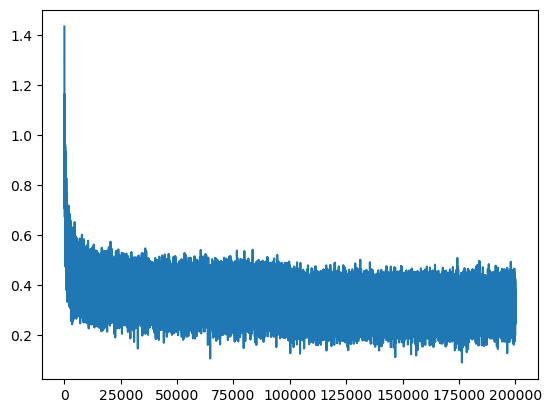

In [281]:
plt.plot(stepi, lossi)

In [282]:
# Caclulate the loss on the validation set
def get_loss(X, Y):
    emb = C[X]
    h = torch.tanh(emb.view(-1, input_dim) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    return loss.item()

print("Total Loss on train: ", get_loss(X_train, Y_train))
print("Total Loss on validation: ", get_loss(X_val, Y_val))
print("Total Loss on test: ", get_loss(X_test, Y_test))

Total Loss on train:  2.1169567108154297
Total Loss on validation:  2.167998790740967
Total Loss on test:  2.187293767929077


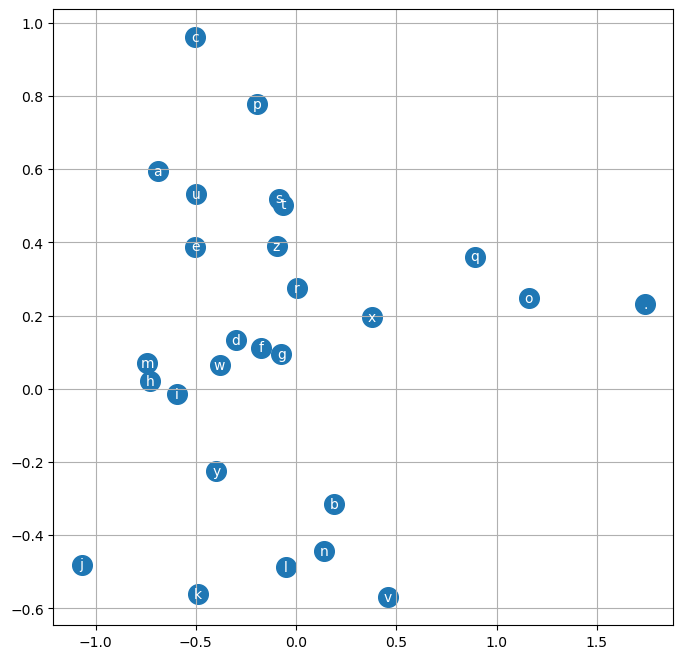

In [283]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [290]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size  # initial context is all 0s (the dot)
    while True:
        emb = C[torch.tensor(context)]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join([itos[i] for i in out]))

junide.
jaycaad.
parlya.
adna.
kovin.
toleta.
juetz.
samela.
yanilenias.
deyah.
rwintlessiyanayva.
ter.
aveumahya.
demmere.
nas.
mah.
jaylyn.
saayae.
octay.
jamille.


C:\Users\Nitin\AppData\Local\Temp\ipykernel_35468\3466860047.py:10: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(logits)
